In [1]:
import functools
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import torch

First, I'll define a function for getting the trajectory give nthe things we'll vary over this problem. We'll start at $(5, 10)$ and optimize until we get within $0.1$ of $(0, 0)$, the global optimum.

In [2]:
@functools.cache
def trajectory(m, weight_decay, objective, maximize):
    theta = torch.tensor([5, 10], dtype=torch.float32, requires_grad=True)
    optim = torch.optim.SGD(
        [theta], momentum=m, weight_decay=weight_decay, maximize=maximize
    )
    steps = []
    while theta.norm() > 0.01:
        steps.append(theta.detach().clone().numpy())
        optim.zero_grad()
        y = objective(*theta)
        y.backward()
        optim.step()
    return np.array(steps)

Then we can take the function over each value of the hyperparameters, $\mu$ for momentum and $\lambda$ for weight decay. I'll use $f(x, y) = x^2 + y^2$ first:

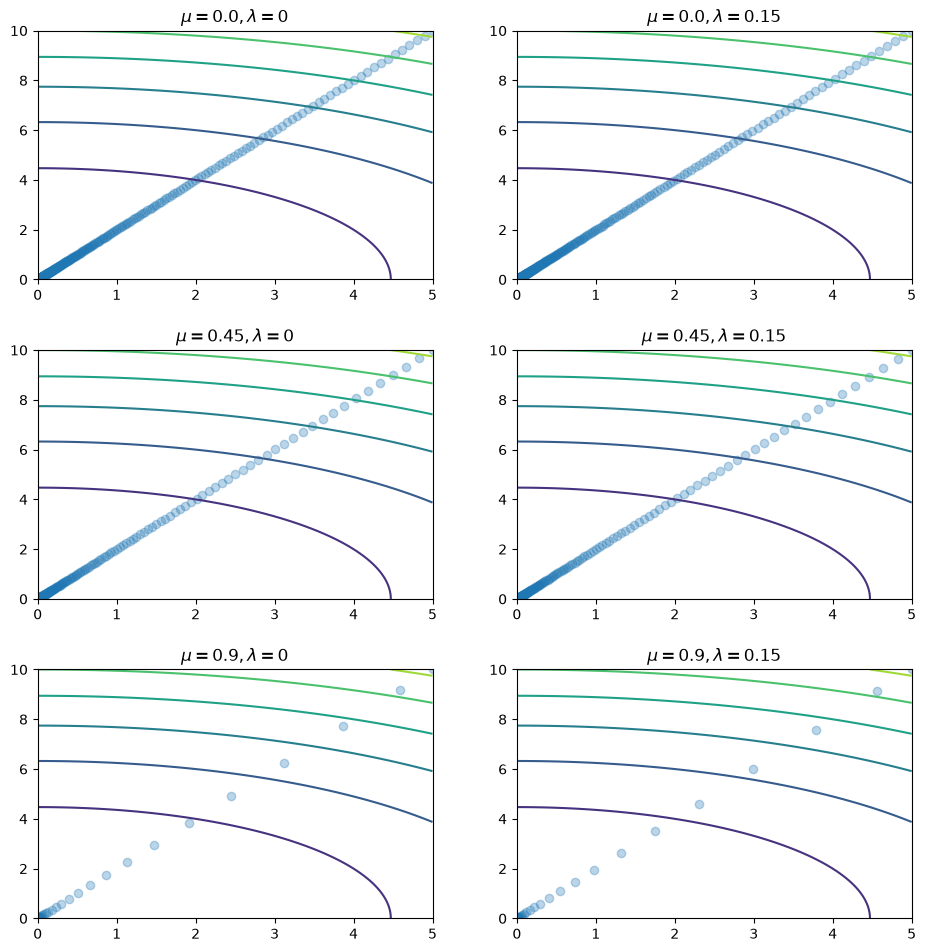

In [3]:
momentums = np.linspace(0, 0.9, 3)
weight_decays = [0, 0.15]


def pos_func(x, y):
    return x**2 + y**2

# setup for the contour plot
x, y = np.meshgrid(np.linspace(0, 5, 100), np.linspace(0, 10, 100))
z = pos_func(x, y)

# setup for trajectory plots
fig, ax = plt.subplots(len(momentums), len(weight_decays))
fig.set_size_inches(10, 10)
plt.tight_layout(pad=3.0)

for (i_m, m), (i_wd, wd) in product(enumerate(momentums), enumerate(weight_decays)):
    steps_np = trajectory(m, wd, pos_func, maximize=False)[::10, :]

    ax[i_m, i_wd].scatter(steps_np[:, 0], steps_np[:, 1], alpha=0.3)
    ax[i_m, i_wd].contour(x, y, z, label=r"$f(x,y)=x^2 + y^2$")

    ax[i_m, i_wd].set_title(rf"$\mu = {m}, \lambda = {wd}$")

Then setting `maximize=True`:

Text(0.5, 1.0, '$\\mu = 0.9, \\lambda = 0.15$')

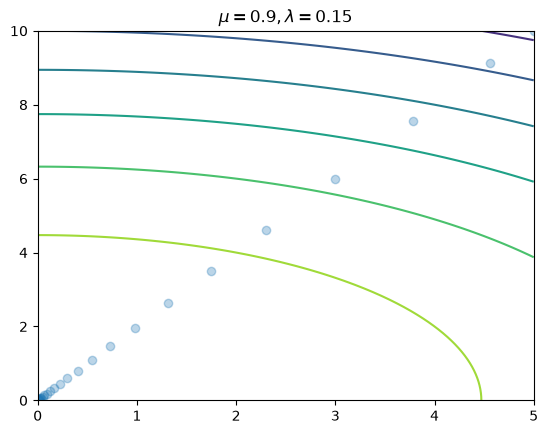

In [4]:
def neg_func(x, y):
    return -x**2 - y**2

# setup for the contour plot
x, y = np.meshgrid(np.linspace(0, 5, 100), np.linspace(0, 10, 100))
z = neg_func(x, y)

# setup for trajectory plots
fig, ax = plt.subplots()

steps_np = trajectory(m, wd, neg_func, maximize=True)[::10, :]

ax.scatter(steps_np[:, 0], steps_np[:, 1], alpha=0.3)
ax.contour(x, y, z, label=r"$f(x,y)=-x^2 - y^2$")
ax.set_title(rf"$\mu = {m}, \lambda = {wd}$")

We can see that the momentum changes the speed at which the optimizer converges; setting a higher momentum meant that the optimizer kept accumulating the gradient steps in its momentum, which all pointed in the same direction. Since the gradient at each step wasn't weighted down with this increase in momentum, that meant that amount the optimizer stepped by at each step was greater for higher momentums.

For weight decay, it's harder to see the difference. However, we can look at the number of steps each took:

The number of steps without weight decay was:

In [5]:
trajectory(0, 0, pos_func, maximize=False).shape[0]

3507

Whereas the number of steps with weight decay $\lambda=0.1$ was 

In [6]:
trajectory(0, 0.1, pos_func, maximize=False).shape[0]

3340

So setting weight decay higher slightly sped up the convergence of the optimizer for this function. This was because the gradient of the loss function had a larger magnitude when weight decay was used; like with momentum, our update was that from when weight decay was $0$, plus another term in the same direction - in this case weight decay. 

This caused the magnitude of each step size to increase, which led to fewer steps/faster convergence.

On the other hand, setting `maximize-True` didn't make a difference, since all that happened was a sign flip everywhere. The sign of the gradient flipped, but the magnitude and direction of it didn't change, and SGD accounts for the sign change by flipping the sign of the gradient when `maxsize` is true. Thus, we ended up taking the same amount of steps.

Number of steps on negative objective with `maximize=True`

In [7]:
trajectory(0, 0, pos_func, maximize=False).shape[0]

3507

Number of steps on positive objective with `maximize=False`

In [8]:
trajectory(0, 0, neg_func, maximize=True).shape[0]

3507